In [1]:
import os
import cv2
import random
import itertools
import numpy as np 
import pandas as pd

import torch
import torch.nn as nn
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import albumentations as A
import matplotlib.pyplot as plt

import segmentation_models_pytorch as smp

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.cuda.manual_seed(seed)
set_seed(0)

In [3]:
def create_df(IMAGE_PATH):
    name = []
    for dirname, _, filenames in os.walk(IMAGE_PATH):
        for filename in filenames:
            folder_name = os.path.basename(dirname)
            full_name = f"{filename.split('.')[0]}"
            name.append(full_name)
    return pd.DataFrame({'id': name}, index=np.arange(0, len(name)))

In [4]:
class CloudDataset(Dataset):
    def __init__(self, img_path, X, Y=None, mean=None, std=None, transform=None):
        self.img_path = img_path
        self.X = X
        self.Y = Y
        self.transform = transform
        self.mean = mean
        self.std = std
        self.has_label = Y is not None

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        img = cv2.imread(self.img_path + self.X[idx] + '.jpg')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            img = Image.fromarray(self.transform(image=img)['image'])
        else:
            img = Image.fromarray(img)
        
        t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
        img = t(img)
        
        if self.has_label:
            label = self.Y[idx]
            return img, label
        else:
            return img

In [5]:
batch_size = 1
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

In [6]:
t_train = A.Compose([A.Resize(320, 416, interpolation=cv2.INTER_AREA)])
t_valid = A.Compose([A.Resize(320, 416, interpolation=cv2.INTER_AREA)])

In [7]:
IMAGE_PATH_TRAIN = '../target_train/'
IMAGE_PATH_VALID = '../target_valid/'
df_train = create_df(IMAGE_PATH_TRAIN)
df_valid = create_df(IMAGE_PATH_VALID)

df_train_radiation = pd.read_csv('./radiation_train.csv')
df_valid_radiation = pd.read_csv('./radiation_valid.csv')

X_train = df_train['id'].values
X_valid = df_valid['id'].values
Y_train = df_train_radiation['Radiation(Ldown-Lup)(Wm^2)'].values
Y_valid = df_valid_radiation['Radiation(Ldown-Lup)(Wm^2)'].values

train_set = CloudDataset(IMAGE_PATH_TRAIN, X_train, Y_train, mean, std, t_train)
valid_set = CloudDataset(IMAGE_PATH_VALID, X_valid, Y_valid, mean, std, t_valid)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False)

In [8]:
base_model = smp.Unet('timm-mobilenetv3_large_100', encoder_weights='imagenet', classes=9,
                 activation=None, encoder_depth=5, decoder_channels=[256, 128, 64, 32, 16])

In [9]:
class ModelWithIntermediate(nn.Module):
    def __init__(self, encoder, classifier):
        super(ModelWithIntermediate, self).__init__()
        self.encoder = encoder
        self.pool = classifier[0]
        self.flatten = classifier[1]
        self.fc1 = classifier[2]  # nn.Linear(960, reduced_dimension)
        # self.fc2 = classifier[3]  # removed this layer

    def forward(self, x):
        features = self.encoder(x)
        if isinstance(features, (list, tuple)):
            features = features[-1]
        x = self.pool(features)
        x = self.flatten(x)
        reduced_features = self.fc1(x)  # run to here
        return reduced_features

In [10]:
encoder = base_model.encoder
encoder_out_channels = 960
reduced_dimension = 6 # the best dimension after testing different dimensions

classifier = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(encoder_out_channels, reduced_dimension),
    nn.Linear(reduced_dimension, 1)
)

model = ModelWithIntermediate(encoder, classifier)

In [11]:
checkpoint = torch.load("6_best.pth", map_location="cpu")
encoder_state_dict = {k.replace("encoder.model.", ""): v for k, v in checkpoint.items() if k.startswith("encoder.model.")}
classifier_state_dict = {k: v for k, v in checkpoint.items() if k.startswith("classifier.2")}
model.encoder.load_state_dict(encoder_state_dict, strict=True)
model.fc1.load_state_dict({
    "weight": classifier_state_dict["classifier.2.weight"],
    "bias": classifier_state_dict["classifier.2.bias"]
})

<All keys matched successfully>

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.eval()

# --------------- train_loader ---------------
train_all_imgs = []
train_all_features = []
train_all_labels = []

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        feats = model(imgs)
        train_all_labels.append(labels.cpu())
        train_all_features.append(feats.cpu())
        
train_all_features = torch.cat(train_all_features, dim=0).numpy()
train_all_labels = torch.cat(train_all_labels, dim=0).numpy()  # (N_train, feature_dim)

# --------------- valid_loader ---------------
valid_all_labels = []
valid_all_features = []

with torch.no_grad():
    for imgs, labels in valid_loader:
        imgs = imgs.to(device)
        feats = model(imgs)
        valid_all_labels.append(labels.cpu())
        valid_all_features.append(feats.cpu())

valid_all_labels = torch.cat(valid_all_labels, dim=0).numpy()
valid_all_features = torch.cat(valid_all_features, dim=0).numpy()  # (N_valid, feature_dim)

In [14]:
# all_features, shape (N, reduced_dimension)
df = pd.DataFrame({
    'Feature 0': train_all_features[:, 0],
    'Feature 1': train_all_features[:, 1],
    'Label': train_all_labels
})

fig = px.scatter(
    df,
    x='Feature 0',
    y='Feature 1',
    color='Label',
    color_continuous_scale='Jet',
    title='2D Feature Visualization (Feature 0 vs Feature 1)',
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(
    title=dict(
        text="2D Feature Visualization (Feature 0 vs Feature 1)",
        x=0.5,
        y=0.93,
        xanchor='center',
        yanchor='top',
        font=dict(size=30)
    ),
    width=800,
    height=650,
    xaxis=dict(
        title='Feature 0',
        titlefont=dict(size=24),
        tickfont=dict(size=21)
    ),
    yaxis=dict(
        title='Feature 1',
        titlefont=dict(size=24),
        tickfont=dict(size=21)
    ),
    legend=dict(
        title=dict(text='Value', font=dict(size=24)),
        font=dict(size=21),
    )
)

fig.show()

In [15]:
n_components_range = range(2, 21)
sse, davies_bouldin, calinski_harabasz, silhouette = [], [], [], []

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='tied', random_state=42)
    cluster_labels = gmm.fit_predict(train_all_features)

    # Sum of Squared Errors
    sse_val = np.sum([
        np.sum((train_all_features[i] - gmm.means_[cluster_labels[i]]) ** 2)
        for i in range(len(train_all_features))
    ])
    sse.append(sse_val)

    # Davies-Bouldin
    davies_bouldin.append(davies_bouldin_score(train_all_features, cluster_labels))

    # Calinski-Harabasz
    calinski_harabasz.append(calinski_harabasz_score(train_all_features, cluster_labels))

    # Silhouette score
    silhouette.append(silhouette_score(train_all_features, cluster_labels))

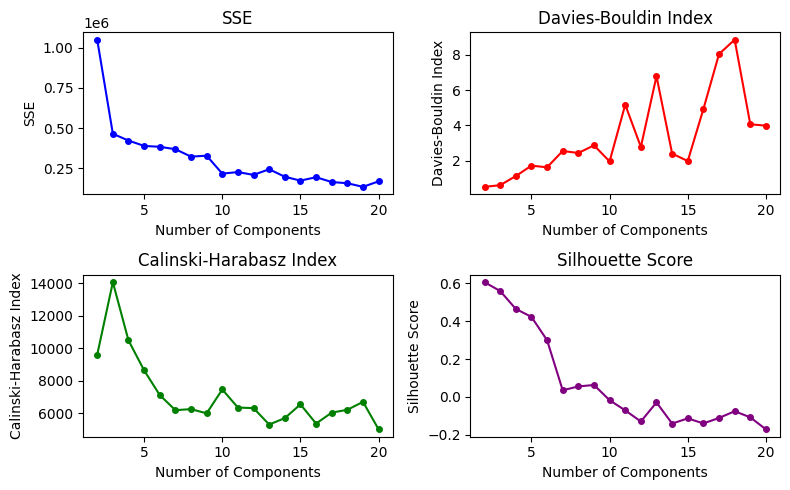

In [16]:
# compare different metrics to determine the best number of clusters
plt.figure(figsize=(8, 5))

plt.subplot(2, 2, 1)
plt.plot(n_components_range, sse, marker='o', linestyle='-', color='b', markersize=4)
plt.title('SSE')
plt.xlabel('Number of Components')
plt.ylabel('SSE')

plt.subplot(2, 2, 2)
plt.plot(n_components_range, davies_bouldin, marker='o', linestyle='-', color='r', markersize=4)
plt.title('Davies-Bouldin Index')
plt.xlabel('Number of Components')
plt.ylabel('Davies-Bouldin Index')

plt.subplot(2, 2, 3)
plt.plot(n_components_range, calinski_harabasz, marker='o', linestyle='-', color='g', markersize=4)
plt.title('Calinski-Harabasz Index')
plt.xlabel('Number of Components')
plt.ylabel('Calinski-Harabasz Index')

plt.subplot(2, 2, 4)
plt.plot(n_components_range, silhouette, marker='o', linestyle='-', color='purple', markersize=4)
plt.title('Silhouette Score')
plt.xlabel('Number of Components')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [17]:
n_components = 3
gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
cluster_labels = gmm.fit_predict(train_all_features)
cluster_labels = cluster_labels + 1

In [18]:
df = pd.DataFrame({
    'Feature 0': train_all_features[:, 0],
    'Feature 1': train_all_features[:, 1],
})

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['Feature 0'],
    y=df['Feature 1'],
    mode='markers',
    name='Data Points',
    marker=dict(size=8, color='gray'),
    showlegend=False
))

fig.update_layout(
    width=1600,
    height=1300,
    annotations=[
        go.layout.Annotation(
            text="a)",
            align='left',
            showarrow=False,
            xref='paper',
            yref='paper',
            x=0.03,
            y=0.97,
            font=dict(size=64, family="Arial", weight="bold")
        )
    ],
    xaxis=dict(
        title='Feature 0',
        titlefont=dict(size=56, family="Arial", weight="bold"),
        tickfont=dict(size=48, family="Arial", weight="bold")
    ),
    yaxis=dict(
        title='Feature 1',
        titlefont=dict(size=56, family="Arial", weight="bold"),
        tickfont=dict(size=48, family="Arial", weight="bold")
    ),
    margin=dict(l=200, r=10, t=10, b=160),
    template='simple_white',
)

fig.update_xaxes(linewidth=5, linecolor='black', title_standoff=30, tickwidth=4, ticklen=15)
fig.update_yaxes(linewidth=5, linecolor='black', tickwidth=4, ticklen=15)

fig.show()

In [20]:
df = pd.DataFrame({
    'Feature 0': train_all_features[:, 0],
    'Feature 1': train_all_features[:, 1],
    'Cluster Label': cluster_labels.astype(str)
})

# sort cluster labels
ordered_labels = sorted(df['Cluster Label'].unique(), key=lambda x: int(x))
color_seq = px.colors.qualitative.G10
# color_map = {'1': "#7BCA47", '2': "#79AEC5", '3': "#AB7ADC"}
# color_seq = [color_map[label] for label in ordered_labels]

fig = go.Figure()

for i, label in enumerate(ordered_labels):
    cluster_df = df[df['Cluster Label'] == label]
    
    fig.add_trace(go.Scatter(
        x=cluster_df['Feature 0'],
        y=cluster_df['Feature 1'],
        mode='markers',
        marker=dict(size=8, color=color_seq[i]),
        showlegend=False,
        name=f"Cluster {label} data"
    ))
    
    fig.add_trace(go.Scatter(
        x=[None],
        y=[None],
        mode='markers',
        name=f"Cluster {label}",
        marker=dict(size=50, color=color_seq[i]),
        showlegend=True
    ))

fig.update_layout(
    width=1600,
    height=1300,
    annotations=[
        go.layout.Annotation(
            text="b)",
            align='left',
            showarrow=False,
            xref='paper',
            yref='paper',
            x=0.03,
            y=0.97,
            font=dict(size=64, family="Arial", weight="bold")
        )
    ],
    xaxis=dict(
        title='Feature 0',
        titlefont=dict(size=56, family="Arial", weight="bold"),
        tickfont=dict(size=48, family="Arial", weight="bold")
    ),
    yaxis=dict(
        title='Feature 1',
        titlefont=dict(size=56, family="Arial", weight="bold"),
        tickfont=dict(size=48, family="Arial", weight="bold")
    ),
    legend=dict(
        font=dict(size=48, family="Arial", weight="bold"),
        x=0.98,
        y=0.02,
        xanchor='right',
        yanchor='bottom',
    ),
    margin=dict(l=200, r=10, t=10, b=160),
    template='simple_white'
)

fig.update_xaxes(linewidth=5, linecolor='black', title_standoff=30, tickwidth=4, ticklen=15)
fig.update_yaxes(linewidth=5, linecolor='black', tickwidth=4, ticklen=15)

fig.show()

In [ ]:
# color_palette = px.colors.qualitative.G10
# num_dims = train_all_features.shape[1]
# combinations = list(itertools.combinations(range(num_dims), 2))
# cluster_str = cluster_labels.astype(str)
# unique_labels = sorted(list(set(cluster_str)), key=lambda x: int(x))
# label_color_map = {label: color_palette[i % len(color_palette)] for i, label in enumerate(unique_labels)}

# layout_plan = [5, 4, 3, 2, 1]
# total_rows = len(layout_plan)
# max_cols = max(layout_plan)

# fig = make_subplots(
#     rows=total_rows,
#     cols=max_cols,
#     specs=[
#         [{'type': 'xy'} if c < layout_plan[r] else None for c in range(max_cols)]
#         for r in range(total_rows)
#     ],
#     subplot_titles=[f"Feature {i} vs {j}" for i, j in combinations],
#     vertical_spacing=0.1,
#     horizontal_spacing=0.05
# )

# plot_idx = 0
# for row_idx, n_cols in enumerate(layout_plan):
#     for col_idx in range(n_cols):
#         i, j = combinations[plot_idx]
#         for label in unique_labels:
#             mask = cluster_str == label
#             fig.add_trace(
#                 go.Scatter(
#                     x=train_all_features[mask, i],
#                     y=train_all_features[mask, j],
#                     mode='markers',
#                     marker=dict(size=1, color=label_color_map[label]),
#                     showlegend=False
#                 ),
#                 row=row_idx + 1,
#                 col=col_idx + 1
#             )
#         plot_idx += 1

# fig.update_layout(
#     title_text="GMM Clustering across Feature Pairs",
#     title_x=0.5,
#     title_y=0.99,
#     title_font_size=36,
#     height=250 * total_rows,
#     width=350 * max_cols,
#     margin=dict(t=100),
#     showlegend=False,
#     template='simple_white'
# )

# for annotation in fig['layout']['annotations']:
#     annotation['font'] = dict(size=30)

# fig.show()

In [ ]:
# set n_components for GMM clustering
n_components = 3
gmm = GaussianMixture(n_components=n_components, covariance_type='tied', random_state=42)
cluster_labels = gmm.fit_predict(train_all_features)

# cluster corresponding radiation_values
cluster_radiation_values = [[] for _ in range(n_components)]
for i in range(len(cluster_labels)):
    cluster_radiation_values[cluster_labels[i]].append(train_all_labels[i])

In [24]:
# test(validation) dataset prediction 
test_cluster_labels = gmm.predict(valid_all_features)
test_cluster_radiation_values = [[] for _ in range(n_components)]
for i in range(len(test_cluster_labels)):
    test_cluster_radiation_values[test_cluster_labels[i]].append(valid_all_labels[i])

In [25]:
records = []
for i in range(n_components):
    cluster_name = f"Cluster {i+1}"  # change 0-based to 1-based
    for val in cluster_radiation_values[i]:
        records.append({"Radiation": val, "Cluster": cluster_name, "Type": "Train"})
    for val in test_cluster_radiation_values[i]:
        records.append({"Radiation": val, "Cluster": cluster_name, "Type": "Test"})

df_violin = pd.DataFrame.from_records(records)

cluster_medians = df_violin[df_violin["Type"] == "Train"].groupby("Cluster")["Radiation"].median()
sorted_clusters = cluster_medians.sort_values().index.tolist()
df_violin["Cluster"] = pd.Categorical(df_violin["Cluster"], categories=sorted_clusters, ordered=True)

fig = px.violin(
    df_violin,
    x="Cluster",
    y="Radiation",
    color="Type",
    box=True,
    points=False,
    color_discrete_map={"Train": "#2a9d8f", "Test": "#e76f51"},
    # color_discrete_map={"Train": "#89C65C", "Test": "#39BCBC"},
    category_orders={"Cluster": sorted_clusters}
)

fig.update_layout(
    title=dict(
        x=0.5, y=0.94,
        font=dict(size=30)
    ),
    xaxis_title="Cluster (Sorted by Train Median Radiation)",
    yaxis_title="NLW radiation (W/m<sup>2</sup>)",
    xaxis_title_font=dict(size=48,family="Arial",weight='bold'),
    yaxis_title_font=dict(size=48,family="Arial",weight='bold'),
    xaxis_tickfont=dict(size=36,family="Arial",weight='bold'),
    yaxis_tickfont=dict(size=36,family="Arial",weight='bold'),
    violingap=0.2,
    height=800,
    width=1600,
    legend=dict(
        title_text="",
        x=0.99, y=0.03,
        xanchor='right',
        yanchor='bottom',
        font=dict(size=40,family="Arial",weight='bold'),
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=3
    ),
    margin=dict(l=160, r=10, t=10, b=150),
    template='simple_white',
    xaxis=dict(showline=True, linewidth=3, linecolor='black', title_standoff=30, tickwidth=4, ticklen=15),
    yaxis=dict(showline=True, linewidth=3, linecolor='black', tickwidth=4, ticklen=15)
 )

fig.show()

In [26]:
data = []
for i in range(n_components):
    cluster = i+1 # 1-based cluster label
    train_count = len(cluster_radiation_values[i])
    test_count = len(test_cluster_radiation_values[i])
    data.append({
        "Cluster": cluster,
        "Train_Count": train_count,
        "Test_Count": test_count
    })

summary_df = pd.DataFrame(data)
summary_df

,Cluster,Train_Count,Test_Count
0,1,844,215
1,2,996,242
2,3,3224,809
